# Bank Customer Churn Prediction

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler,SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

In [2]:
df=pd.read_csv('Churn_Modelling.csv')

In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [6]:
df.shape

(10000, 14)

In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Dataset is clear no duplicates and no null values

#### Split dataset

In [10]:
x = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = df['Exited']


#### Encoding

In [11]:
x['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [12]:
x['Gender'] = x['Gender'].map({'Male': 1, 'Female': 0})


In [13]:
x['Gender'].dtype

dtype('int64')

##### Onehot encoding

In [14]:
x['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [15]:
onehot=OneHotEncoder(drop='first',sparse_output=False)
onehot.fit(df[['Geography']])

OneHotEncoder(drop='first', sparse_output=False)

In [16]:
x=pd.get_dummies(x,columns=['Geography'],drop_first=True,dtype=int)


In [17]:
x

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,0
9997,709,0,36,7,0.00,1,0,1,42085.58,0,0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0


## Outliers

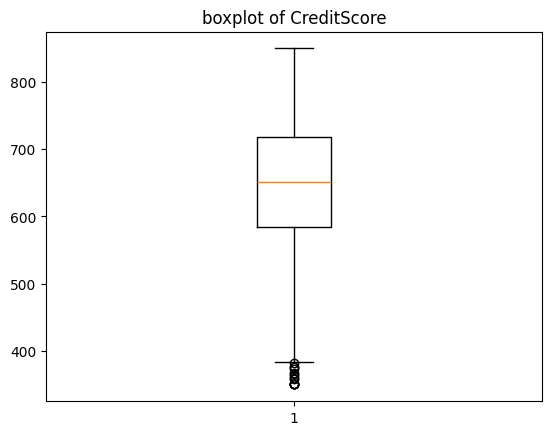

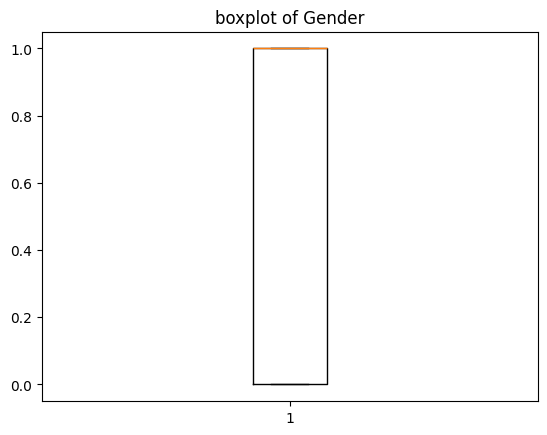

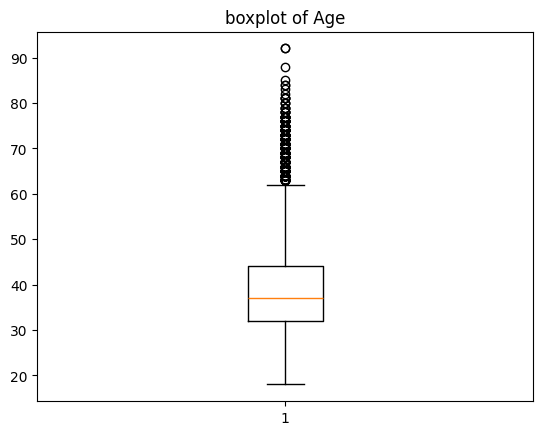

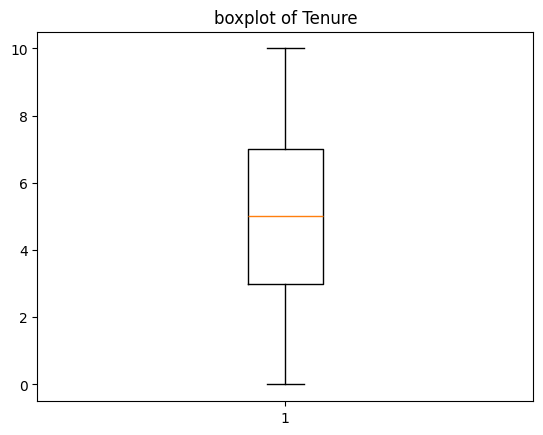

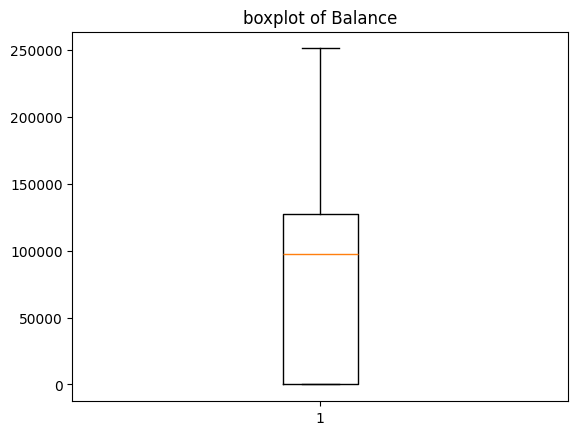

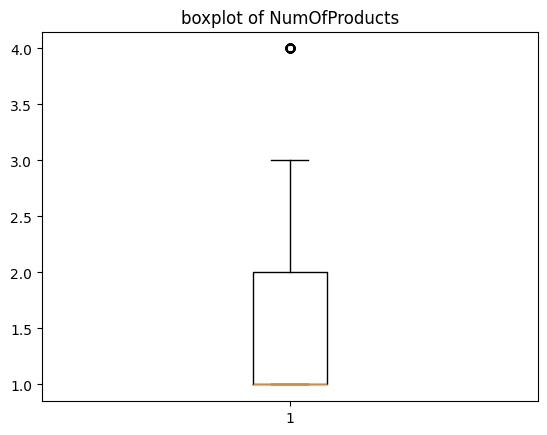

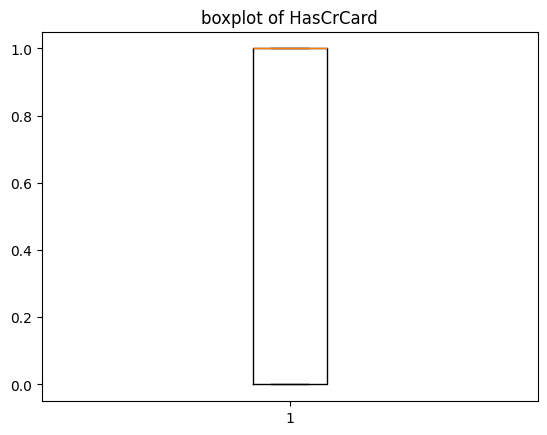

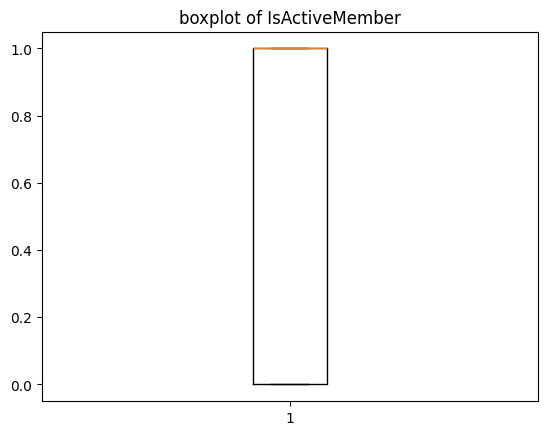

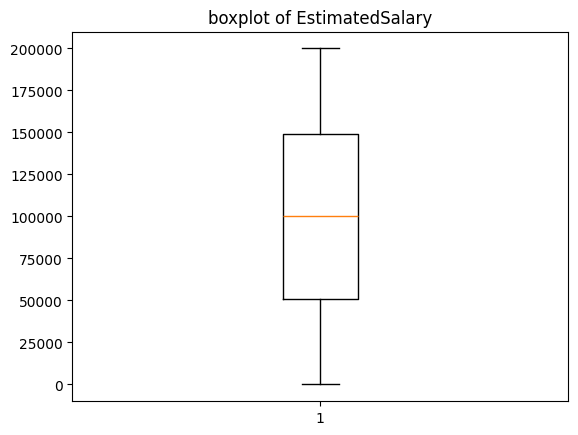

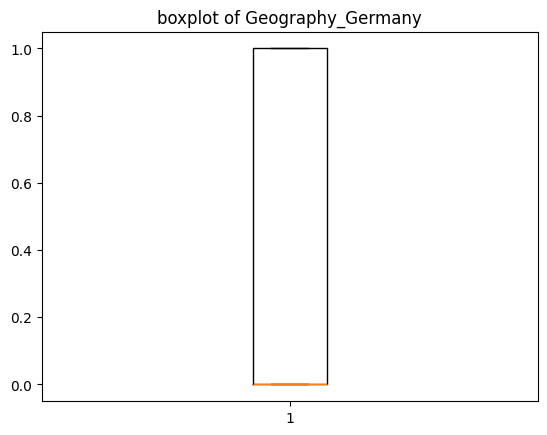

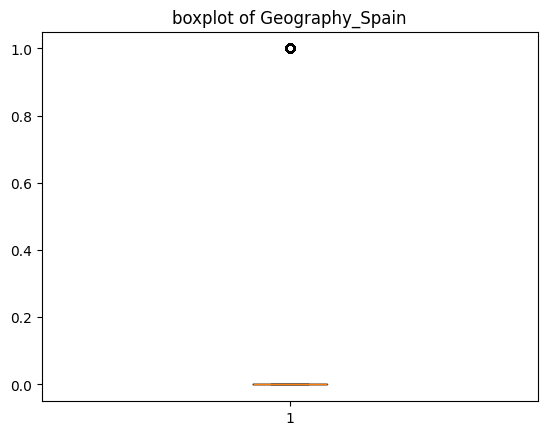

In [18]:
for i in x:
    if x[i].dtype in ['int','float']:
        plt.boxplot(x[i])
        plt.title(f"boxplot of {i}")
        plt.show()

Age and Numofproducts have outliers

In [19]:
x['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

In [20]:
x['NumOfProducts'].describe()

count    10000.000000
mean         1.530200
std          0.581654
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: NumOfProducts, dtype: float64

In [21]:
q1=x['Age'].quantile(0.25)
q3=x['Age'].quantile(0.75)
iqr=q3-q1
q3+1.5*iqr

np.float64(62.0)

In [22]:
df.loc[df['Age']>62,'Exited'].value_counts()


Exited
0    286
1     73
Name: count, dtype: int64

In [23]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [24]:
q1=x['NumOfProducts'].quantile(0.25)
q3=x['NumOfProducts'].quantile(0.75)
iqr=q3-q1
q3+1.5*iqr

np.float64(3.5)

In [25]:
df.loc[df['NumOfProducts']>3.5,'Exited'].value_counts()

Exited
1    60
Name: count, dtype: int64

In [26]:
print(x.dtypes)


CreditScore            int64
Gender                 int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Geography_Germany      int64
Geography_Spain        int64
dtype: object


## Splitting

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

## Scaling

In [28]:
minmax=MinMaxScaler()
x_scaled=minmax.fit_transform(x)


## Sampling

In [29]:
y.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [30]:
sampler = Pipeline([
    ("over", SMOTE(sampling_strategy={1:5000})),     
    ("under", RandomUnderSampler(sampling_strategy={0:5000}))  
])

In [31]:
x_sampled,y_sampled=sampler.fit_resample(x_scaled,y)

c:\Users\intel-asuz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\intel-asuz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\intel-asuz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\intel-asuz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is depr

In [32]:
y_sampled.value_counts()

Exited
0    5000
1    5000
Name: count, dtype: int64

## Model testing and training

KNeighborsClassifier
________________________________________________________________________________________________________________________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2389
           1       0.24      0.08      0.12       611

    accuracy                           0.76      3000
   macro avg       0.52      0.51      0.49      3000
weighted avg       0.69      0.76      0.71      3000



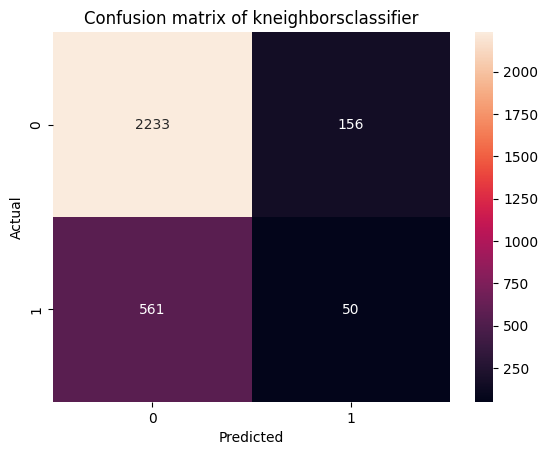

________________________________________________________________________________________________________________________________________________________________________________________________________


SVC
________________________________________________________________________________________________________________________________________________________________________________________________________


c:\Users\intel-asuz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\intel-asuz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\intel-asuz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      2389
           1       0.00      0.00      0.00       611

    accuracy                           0.80      3000
   macro avg       0.40      0.50      0.44      3000
weighted avg       0.63      0.80      0.71      3000



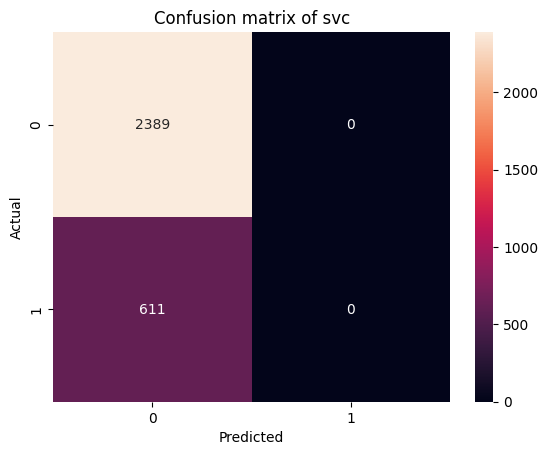

________________________________________________________________________________________________________________________________________________________________________________________________________


GradientBoostingClassifier
________________________________________________________________________________________________________________________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      2389
           1       0.75      0.46      0.57       611

    accuracy                           0.86      3000
   macro avg       0.81      0.71      0.74      3000
weighted avg       0.85      0.86      0.85      3000



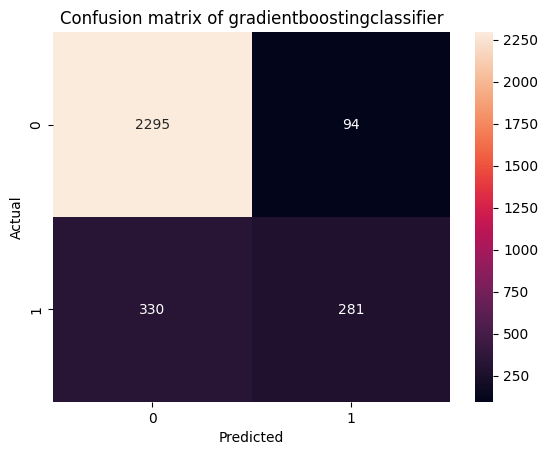

________________________________________________________________________________________________________________________________________________________________________________________________________


DecisionTreeClassifier
________________________________________________________________________________________________________________________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      2389
           1       0.48      0.51      0.49       611

    accuracy                           0.79      3000
   macro avg       0.68      0.68      0.68      3000
weighted avg       0.79      0.79      0.79      3000



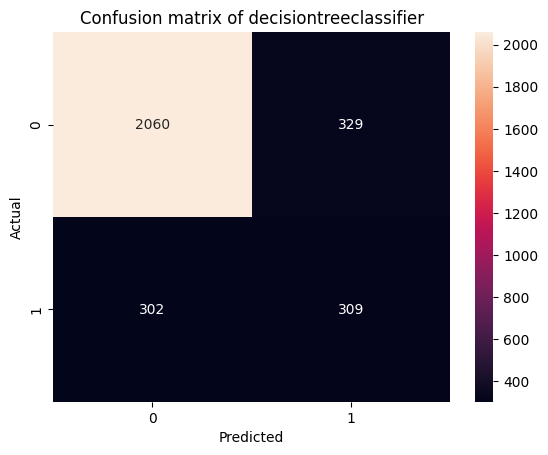

________________________________________________________________________________________________________________________________________________________________________________________________________


GaussianNB
________________________________________________________________________________________________________________________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      2389
           1       0.40      0.08      0.14       611

    accuracy                           0.79      3000
   macro avg       0.60      0.53      0.51      3000
weighted avg       0.72      0.79      0.73      3000



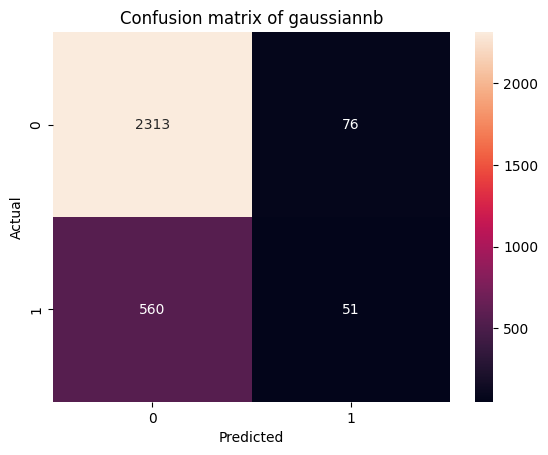

________________________________________________________________________________________________________________________________________________________________________________________________________


XGBClassifier
________________________________________________________________________________________________________________________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      2389
           1       0.67      0.49      0.57       611

    accuracy                           0.85      3000
   macro avg       0.77      0.71      0.74      3000
weighted avg       0.84      0.85      0.84      3000



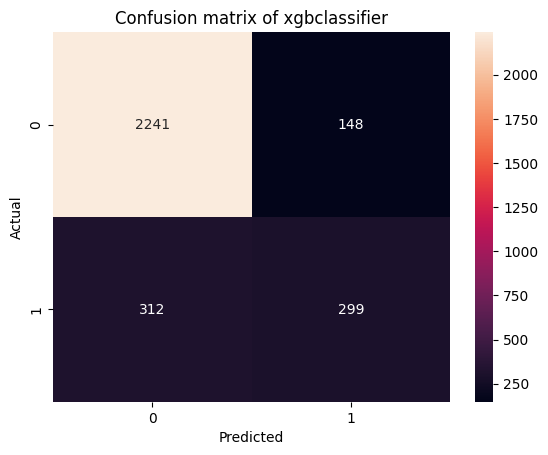

________________________________________________________________________________________________________________________________________________________________________________________________________


AdaBoostClassifier
________________________________________________________________________________________________________________________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      2389
           1       0.69      0.44      0.54       611

    accuracy                           0.85      3000
   macro avg       0.78      0.70      0.72      3000
weighted avg       0.83      0.85      0.83      3000



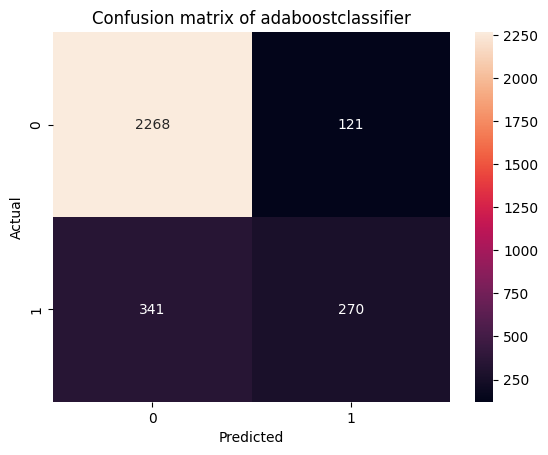

________________________________________________________________________________________________________________________________________________________________________________________________________


RandomForestClassifier
________________________________________________________________________________________________________________________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      2389
           1       0.76      0.46      0.57       611

    accuracy                           0.86      3000
   macro avg       0.82      0.71      0.74      3000
weighted avg       0.85      0.86      0.85      3000



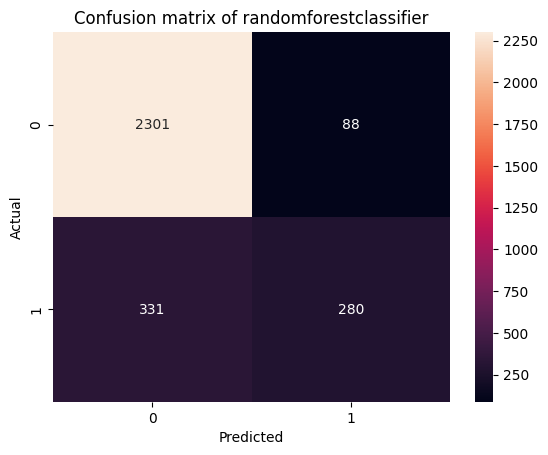

________________________________________________________________________________________________________________________________________________________________________________________________________




In [33]:
models=[KNeighborsClassifier(),SVC(),GradientBoostingClassifier(),DecisionTreeClassifier(),GaussianNB(),XGBClassifier(),AdaBoostClassifier(),RandomForestClassifier()]
for model in models:
    model.fit(x_train,y_train)
    print(str(model).split("(")[0])
    print("__"*100)
    y_pred=model.predict(x_test)
    print(classification_report(y_test,y_pred))
    plt.title(f"Confusion matrix of {str(model).split('(')[0]}".capitalize())
    sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    print("__"*100,end="\n\n\n")


## Cross validation

In [34]:
for model in models:
    print(str(model).split("(")[0])
    print(cross_val_score(model,x_sampled,y_sampled,cv=5).mean())

KNeighborsClassifier
0.7978
SVC
0.7691000000000001
GradientBoostingClassifier
0.8335000000000001
DecisionTreeClassifier
0.7864000000000001
GaussianNB
0.7167
XGBClassifier
0.8554999999999999
AdaBoostClassifier
0.789
RandomForestClassifier
0.8651


### Hyperparametric Tuning

In [35]:
parameter={"n_estimators":[10,100,200,300,500,700],
           "criterion":['gini','entropy',"log_loss"],
           'max_depth':[3,7,10,20,30,100,200]}
grid=RandomizedSearchCV(RandomForestClassifier(),parameter,cv=5,n_iter=20)
grid.fit(x_sampled,y_sampled)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [3, 7, 10, 20, 30, 100,
                                                      200],
                                        'n_estimators': [10, 100, 200, 300, 500,
                                                         700]})

In [36]:
grid.best_params_

{'n_estimators': 300, 'max_depth': 200, 'criterion': 'entropy'}

In [37]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.472695,0.056420,0.019267,0.003718,10,100,gini,"{'n_estimators': 10, 'max_depth': 100, 'criter...",0.7935,0.7785,0.8835,0.8935,0.8780,0.8454,0.048984,13
1,11.162297,0.535752,0.233246,0.006389,200,30,entropy,"{'n_estimators': 200, 'max_depth': 30, 'criter...",0.8210,0.8135,0.8895,0.9160,0.8990,0.8678,0.042205,8
2,3.265119,0.497129,0.083345,0.014699,100,7,gini,"{'n_estimators': 100, 'max_depth': 7, 'criteri...",0.7725,0.7695,0.8320,0.8475,0.8375,0.8118,0.033695,17
3,9.460481,0.956792,0.246203,0.080940,500,3,log_loss,"{'n_estimators': 500, 'max_depth': 3, 'criteri...",0.7590,0.7490,0.7955,0.7960,0.7785,0.7756,0.018993,19
4,0.446966,0.068314,0.018995,0.004711,10,30,gini,"{'n_estimators': 10, 'max_depth': 30, 'criteri...",0.7945,0.7940,0.8795,0.8880,0.8880,0.8488,0.044648,12
5,77.792711,96.534952,0.534731,0.188057,700,10,entropy,"{'n_estimators': 700, 'max_depth': 10, 'criter...",0.7845,0.7780,0.8540,0.8740,0.8605,0.8302,0.040537,15
6,1.318162,0.640015,0.047745,0.042143,10,30,log_loss,"{'n_estimators': 10, 'max_depth': 30, 'criteri...",0.8050,0.7945,0.8825,0.8955,0.8850,0.8525,0.043418,10
7,21.902688,14.922926,0.341476,0.031598,700,200,entropy,"{'n_estimators': 700, 'max_depth': 200, 'crite...",0.8185,0.8180,0.8950,0.9210,0.9025,0.8710,0.043894,2
8,10.795945,0.414354,0.298826,0.042260,700,20,gini,"{'n_estimators': 700, 'max_depth': 20, 'criter...",0.8210,0.8140,0.8925,0.9210,0.8990,0.8695,0.043552,4
9,5.854548,0.109407,0.137656,0.023178,300,30,entropy,"{'n_estimators': 300, 'max_depth': 30, 'criter...",0.8220,0.8130,0.8960,0.9170,0.8990,0.8694,0.043075,5


In [38]:
grid.best_score_

np.float64(0.8711)

In [39]:
final=grid.best_estimator_

In [40]:
final.predict(x_test)

c:\Users\intel-asuz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


array([1, 1, 1, ..., 1, 1, 1])

## Data convert to Streamlit 

In [41]:
import pickle 
data={'model':model,'scaler':minmax,'onehot':onehot,"feature_names": x.columns,'df':df}
with open('Churn.pkl','wb') as obj1:
    pickle.dump(data,obj1)

In [42]:
with open("Churn.pkl","rb") as obj1:
    a=pickle.load(obj1)